In [2]:
import pandas as pd
import random
import numpy as np

In [3]:
data=[]

for _ in range(500):
    team_name=f"Team {chr(random.randint(65,90))}"
    season= random.randint(2010,2023)
    wins=random.randint(50,110)
    losses=162-wins
    hits=random.randint(1200,1600)
    doubles= random.randint(200,350)
    triples=random.randint(10,40)
    home_runs=random.randint(100,250)
    strikeouts=random.randint(1000,1500)
    
    hits_adjusted=hits +(wins-80)*5
    doubles_adjusted= doubles +(wins-80)*3
    triples_adjusted= triples +(wins-80)
    home_runs= home_runs +(wins-80)*3
    strikeouts_adjusted  =   strikeouts -(wins-80)*10
    
    data.append([team_name,season,wins,losses,hits_adjusted,doubles_adjusted,triples_adjusted,home_runs,strikeouts_adjusted])  

In [4]:
columns=['Team','Season','Wins','Losses','Hits','Doubles','Triples','HomeRuns','StrikeOuts']

In [5]:
df=pd.DataFrame(data,columns=columns) 
df.head()

,Team,Season,Wins,Losses,Hits,Doubles,Triples,HomeRuns,StrikeOuts
0,Team S,2017,58,104,1303,144,10,80,1381
1,Team V,2019,73,89,1393,324,32,158,1445
2,Team I,2023,90,72,1548,328,43,223,1099
3,Team T,2023,74,88,1255,279,13,211,1307
4,Team N,2023,67,95,1202,176,9,98,1585


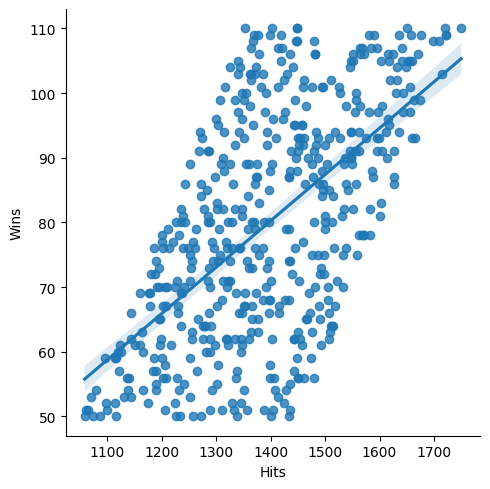

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.lmplot(x='Hits',y='Wins',data=df)
plt.show()

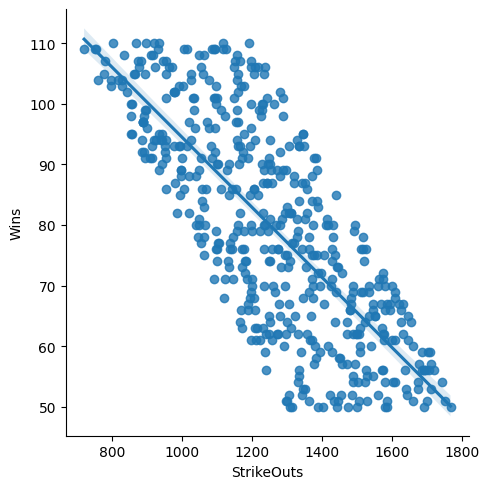

In [8]:
sns.lmplot(x='StrikeOuts',y='Wins',data=df)

In [9]:
df2=df.drop(columns=['Team','Season','Losses'])

In [10]:
df2.head()

,Wins,Hits,Doubles,Triples,HomeRuns,StrikeOuts
0,58,1303,144,10,80,1381
1,73,1393,324,32,158,1445
2,90,1548,328,43,223,1099
3,74,1255,279,13,211,1307
4,67,1202,176,9,98,1585


In [11]:
df2.columns

Index(['Wins', 'Hits', 'Doubles', 'Triples', 'HomeRuns', 'StrikeOuts'], dtype='str')

In [12]:
X=df[['Hits','Doubles','Triples','HomeRuns','StrikeOuts']]
y=df['Wins']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=0.2, random_state=24)

In [15]:
from sklearn.linear_model import LinearRegression

In [17]:
lr=LinearRegression( )

In [18]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
lr.score(X_test,y_test)

0.8901054536124969

In [21]:
lr.score(X_train,y_train)

0.8979143125784609

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [23]:
y_pred=lr.predict(X_test)

In [24]:
mean_absolute_error(y_test,y_pred)

4.818668467631459

In [25]:
mean_squared_error(y_test,y_pred)

34.82333990145342

In [26]:
r2_score(y_test,y_pred)

0.8901054536124969

In [27]:
lr.coef_

array([ 0.00718561,  0.05033256,  0.4034582 ,  0.05176945, -0.01461618])

In [28]:
lr.intercept_

np.float64(54.88728009507875)